In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('eda_output.csv')

In [3]:
data.head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,default
0,10000.0,36 months,11.44,329.48,B,B4,10+ years,RENT,117000.0,Not Verified,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,0
1,8000.0,36 months,11.99,265.68,B,B5,4 years,MORTGAGE,65000.0,Not Verified,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,0
2,15600.0,36 months,10.49,506.97,B,B3,< 1 year,RENT,43057.0,Source Verified,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,0
3,7200.0,36 months,6.49,220.65,A,A2,6 years,RENT,54000.0,Not Verified,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,0
4,24375.0,60 months,17.27,609.33,C,C5,9 years,MORTGAGE,55000.0,Verified,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,1


<Axes: xlabel='annual_inc', ylabel='Count'>

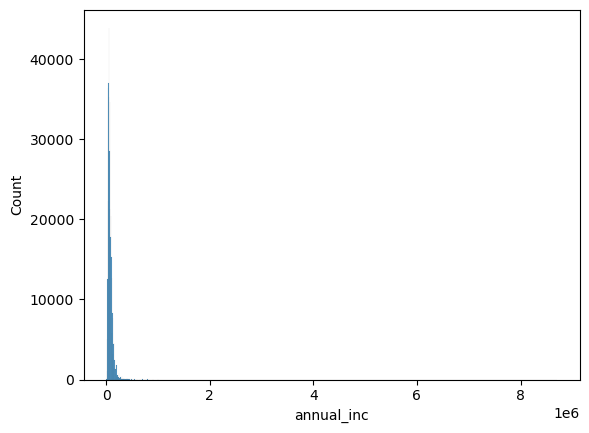

In [4]:
sns.histplot(data['annual_inc'])

In [5]:
# Outlier Handling

In [6]:
data['annual_inc']=np.log1p(data['annual_inc'])

In [7]:
data['revol_bal']=np.log1p(data['revol_bal'])

In [8]:
data['annual_inc']

0         11.669938
1         11.082158
2         10.670303
3         10.896758
4         10.915107
            ...    
396025    10.596660
396026    11.608245
396027    10.942014
396028    11.066654
396029    10.668886
Name: annual_inc, Length: 396030, dtype: float64

In [9]:
data['revol_bal']

0         10.501500
1          9.910066
2          9.391661
3          8.607582
4         10.109892
            ...    
396025     7.596392
396026    10.675076
396027    10.395283
396028     9.661734
396029     8.364741
Name: revol_bal, Length: 396030, dtype: float64

In [10]:
#Feature Engineering

In [11]:
# 1. Loan to Income Ratio
#     Loan_Ratio = loan/annual_income

data['loan_income_ratio']=(data.loan_amnt /np.expm1(data.annual_inc))

In [12]:
data['loan_income_ratio']

0         0.085470
1         0.123077
2         0.362310
3         0.133333
4         0.443182
            ...   
396025    0.250000
396026    0.190909
396027    0.088496
396028    0.328125
396029    0.046516
Name: loan_income_ratio, Length: 396030, dtype: float64

In [13]:
# 2. Installment Burden
#  Installment_Burden = Installment/annual_income
data['installment_income_ratio']=(data.installment /np.expm1(data.annual_inc))

In [14]:
data['installment_income_ratio']

0         0.002816
1         0.004087
2         0.011774
3         0.004086
4         0.011079
            ...   
396025    0.005435
396026    0.006367
396027    0.002855
396028    0.007860
396029    0.001581
Name: installment_income_ratio, Length: 396030, dtype: float64

In [15]:
# 3. Bankruptcy Flag [Yes or No / 0 or 1]
data['has_bankruptcy']=(data.pub_rec_bankruptcies>0).astype(int)

In [16]:
data['has_bankruptcy']

0         0
1         0
2         0
3         0
4         0
         ..
396025    0
396026    0
396027    0
396028    0
396029    0
Name: has_bankruptcy, Length: 396030, dtype: int64

In [17]:
# 4. Public Record Risk
data['public_record_risk']=(data.pub_rec+data.pub_rec_bankruptcies)

In [18]:
data['public_record_risk']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
396025    0.0
396026    0.0
396027    0.0
396028    0.0
396029    0.0
Name: public_record_risk, Length: 396030, dtype: float64

In [19]:
# 5. Credit Utilization Category
data['high_utilization']=(data.revol_util>70).astype(int)

In [20]:
data['high_utilization']

0         0
1         0
2         1
3         0
4         0
         ..
396025    0
396026    1
396027    0
396028    0
396029    1
Name: high_utilization, Length: 396030, dtype: int64

In [35]:
data.to_csv("processed_data.csv", index=False)